In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import joblib

print('libraries loaded successfully')

libraries loaded successfully


In [2]:
dt = sns.load_dataset('tips')
dt.head

<bound method NDFrame.head of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [39]:
dt[(dt['total_bill'] >= 13) & (dt['total_bill'] <= 15)]

,total_bill,tip,sex,smoker,day,time,size
9,14.78,3.23,Male,No,Sun,Dinner,2
14,14.83,3.02,Female,No,Sun,Dinner,2
26,13.37,2.00,Male,No,Sat,Dinner,2
42,13.94,3.06,Male,No,Sun,Dinner,2
61,13.81,2.00,Male,Yes,Sat,Dinner,2
74,14.73,2.20,Female,No,Sat,Dinner,2
86,13.03,2.00,Male,No,Thur,Lunch,2
109,14.31,4.00,Female,Yes,Sat,Dinner,2
110,14.00,3.00,Male,No,Sat,Dinner,2
121,13.42,1.68,Female,No,Thur,Lunch,2


<function matplotlib.pyplot.show(close=None, block=None)>

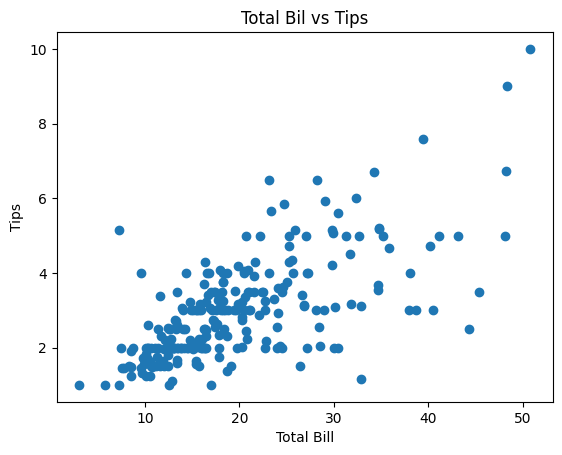

In [3]:
plt.scatter(dt['total_bill'], dt['tip'])
plt.title('Total Bil vs Tips')
plt.xlabel('Total Bill')
plt.ylabel('Tips')
plt.show

In [26]:
x = dt[['total_bill']]
y = dt[['tip']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.7, random_state=32)

In [27]:
models = LinearRegression()
models.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = models.predict(x_test)

In [29]:
y_pred

array([[3.01247876],
       [3.54450883],
       [3.63777307],
       [1.61563488],
       [2.71890839],
       [2.75706194],
       [2.33631306],
       [1.72903571],
       [4.99752322],
       [3.26789559],
       [2.56523436],
       [3.56358561],
       [2.67121645],
       [2.54615759],
       [4.04156481],
       [1.88906866],
       [2.65425932],
       [2.13706674],
       [1.72161696],
       [2.98704306],
       [2.44971389],
       [2.241989  ],
       [3.66638823],
       [2.57689239],
       [2.39142374],
       [2.2112542 ],
       [2.67545573],
       [2.56099508],
       [3.17569117],
       [5.92486647],
       [3.19582777],
       [4.84808848],
       [4.04792374],
       [2.61822541],
       [3.41839015],
       [2.56311472],
       [2.35433001],
       [2.51012368],
       [3.04639303],
       [3.39189463],
       [2.20065599],
       [1.58807954],
       [2.84184761],
       [1.93358114],
       [2.99552163],
       [2.10845158],
       [2.16462208],
       [2.704

In [30]:
print(f'Slope (m): {models.coef_[0]}')
print(f'Intercept (b): {models.intercept_}')

Slope (m): [0.10598209]
Intercept (b): [0.81970942]


In [31]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.3f}')
print(f'Root Mean Squared Error: {rmse:.3f}')
print(f'R-squared score: {r2:.3f}')

Mean Squared Error: 1.168
Root Mean Squared Error: 1.081
R-squared score: 0.423


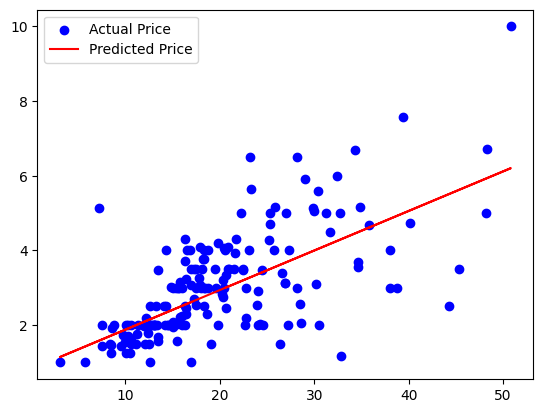

In [32]:
plt.scatter(x_test, y_test, color='blue', label='Actual Price')
plt.plot(x_test, y_pred, color='red', label='Predicted Price')
plt.legend()
plt.show()

In [33]:
joblib.dump(models, 'Tips_Predictor.joblib')

['Tips_Predictor.joblib']

In [34]:
loaded_model = joblib.load('Tips_Predictor.joblib')

In [36]:
new_customer = [[13.50]]
predicted_tip = loaded_model.predict(new_customer)
print(f'Predicted_tip: {predicted_tip[0]}')

Predicted_tip: [2.25046757]


C:\Users\Thathun\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
